In [1]:
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Iterable, List, Set, Tuple, Optional

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

Objašnjenja nekih korištenih f-ja:
* Sigmoidna funkcija $\sigma = \frac{1}{1+e^{-x}}$
* $Top_n(\vec{x}^t)=\arg\max_{i\leq t}^n (x^i),\  n\leq t$ koja vrati $n$ najvećih elemenata vektora $\vec{x}$.
* $Precision@N=\frac{\text{Broj predviđenih artikala koji su zaista među top N}}{\text{Ukupan broj predviđenih artikala}}$

* $Recall@N=\frac{\text{Broj predviđenih artikala koji su zaista među top N}}{\text{Ukupan broj relevantnih artikala}}$
* $F1@N=\frac{2\cdot Precision@N\cdot Recall@N}{Precision@N+Recall@N}$

In [2]:
#lazy eval, za samoreferencirajuće tipove
from __future__ import annotations

import math
import numpy as np
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Iterable

#napravi progress bar... nije nužno ako nemate, samo zakomentiraj ovu liniju i stavite progress=False u trening metodama
from tqdm import tqdm

#ovo će trebati za 
from scipy import sparse


def sigmoid(x: float) -> float:
    # numericki stabilna sigmoidna fja
    #za jako male/jako velike x-eve da sprijecim over/underflow
    if x >= 0:
        # za x>=0 
        #sigmoid(x) = 1/(1+e^-x)
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        #a za vrlo velike negativne x bi moglo biti e^-x ogromno
        #pa zato radim sigmoid(x) = e^x / (1 + e^x)
        z = math.exp(x)
        return z / (1.0 + z)

def bpr_delta(x_uij: float) -> float:
    # delta = (1 - sigmoida(x_uij)) gdje x_uij = rezultat_poz - rezultat_neg
    return 1.0 - float(sigmoid(x_uij))

#ovo je dekorator iz standardne python biblioteke, automatski napravi __init__ i ostali boilerplate kod
@dataclass
class TenzorPodaci:
    """
    Sprema tenzor s oznakama kao promatrane trojke S podskup UxIxT

    trojke: lista (u, i, t)-ova s cjelobrojnim indeksima iz [0..n_k), [0..n_a), [0..n_t)
    """
    n_korisnici: int
    n_artikli: int
    n_oznake: int
    trojke: np.ndarray  # oblika (n_obs, 3), dtype int64

    def sagradi_post_index(self) -> Dict[Tuple[int, int], np.ndarray]:
        """
        Mapiraj svaki post (u,i) polju promatranih oznaka za taj post.
        """
        post_oznake: Dict[Tuple[int, int], List[int]] = {}
        for u, i, t in self.trojke:
            key = (int(u), int(i))
            post_oznake.setdefault(key, []).append(int(t))
        # unique tags per post for correct negative sampling
        return {k: np.array(sorted(set(v)), dtype=np.int64) for k, v in post_oznake.items()}


class BPRUzorkovanje:
    """
    Uzorkuje četvorke (u, i, t_pos, t_neg) uniformno iz D_S.
    Negativne oznake se uzorkuju iz svih oznaka koje nisu u promatranom skupu oznaka za post (skup S).
    """
    def __init__(self, data: TenzorPodaci, seed: int = 42):
        self.data = data
        self.rng = np.random.default_rng(seed)
        self.post_oznake = data.sagradi_post_index() # rječnik oblika (u,i) -> [t1, t2, ...]
        self.postovi = np.array(list(self.post_oznake.keys()), dtype=np.int64)  # oblika (n_postova, 2) - svi postovi, npr [(0,2), (0,4), (3,1), ...]
        self.sve_oznake = np.arange(data.n_oznake, dtype=np.int64)
        self._oznake_skupovi = {k: set(map(int, v)) for k, v in self.post_oznake.items()} #za O(1) lookup "je li oznaka i pozotivna za post j?"

    def uzorkuj(self) -> Tuple[int, int, int, int]:
        u, i = self.postovi[self.rng.integers(0, len(self.postovi))] #uniformno odabire post
        oznake_pos = self.post_oznake[(int(u), int(i))] #dohvatim pozitivne oznake za post
        t_pos = int(oznake_pos[self.rng.integers(0, len(oznake_pos))]) #odabere nasumičnu pozitivnu oznaku za post (postoji jer je p-core skup podataka)

        # sad biram negativnu oznaku (u,i,t_neg) nije element od S
        tagset = self._oznake_skupovi[(int(u), int(i))]
        while True:
            t_neg = int(self.rng.integers(0, self.data.n_oznake)) #nasumicni indeks oznake
            if t_neg not in tagset: 
                break
        return int(u), int(i), t_pos, t_neg



#Modeli faktorizacije

#bazna klasa, sve izvedene implementiraju ove metode
class BazniOznakaModel:
    def score(self, u: int, i: int, t: int) -> float:
        raise NotImplementedError

    def ocijeni_sve_oznake(self, u: int, i: int) -> np.ndarray:
        """
        Vektor ocjena za sve oznake za fiksan post (u,i).
        """
        raise NotImplementedError

    def predlozi(self, u: int, i: int, topn: int = 10) -> np.ndarray:
        #predlaze topn oznaka za post (u,i)
        scores = self.ocijeni_sve_oznake(u, i)
        if topn >= len(scores):
            return np.argsort(-scores)
        # partial top-k
        idx = np.argpartition(-scores, topn)[:topn]
        idx = idx[np.argsort(-scores[idx])]
        return idx


class PITF(BazniOznakaModel):
    """
    PITF model (jednadžba (13)):
        y(u,i,t) = <U[u], TU[t]> + <I[i], TI[t]>
    Parametri:
        U  : (n_korisnici, k)
        I  : (n_artikli, k)
        TU : (n_oznake,  k)
        TI : (n_oznake,  k)
    """
    def __init__(self, n_korisnici: int,
                 n_artikli: int,
                 n_oznake: int,
                 k: int,
                 init_std: float = 0.01,
                 seed: int = 42,
                 optimizator: str | None = None,
                 gama: float = 1e-6,
                 beta1: float = 0.9, #predlozeni pocetni parametri za Adagrad u originalnom radu
                 beta2: float = 0.999,
                 eps: float = 1e-8):
        if optimizator not in (None, "decay", "adam", "adagrad"):
            raise ValueError("optimizator mora biti None, 'decay', 'adam' ili 'adagrad'")

        rng = np.random.default_rng(seed)
        self.k = int(k)

        self.U  = rng.normal(0.0, init_std, size=(n_korisnici, k)).astype(np.float64)
        self.I  = rng.normal(0.0, init_std, size=(n_artikli, k)).astype(np.float64)
        self.TU = rng.normal(0.0, init_std, size=(n_oznake,  k)).astype(np.float64)
        self.TI = rng.normal(0.0, init_std, size=(n_oznake,  k)).astype(np.float64)

        # hiperparametri optimizatora
        self.optimizator = optimizator
        self.gamma = float(gama)
        self.beta1 = float(beta1)
        self.beta2 = float(beta2)
        self.eps = float(eps)

        # inicijalno stanje adama
        self._adam_inicijaliziran = False
        self.t_adam = 0

        # inicijalno stanje adagarda
        self._adagrad_inicijaliziran = False

    def score(self, u: int, i: int, t: int) -> float:
        #vraca \hat{y}_{u,i,t} = <U_u, TU_t> + <I_i, TI_t>
        return float(self.U[u] @ self.TU[t] + self.I[i] @ self.TI[t])

    def ocijeni_sve_oznake(self, u: int, i: int) -> np.ndarray:
        # (n_oznake,)
        return self.TU @ self.U[u] + self.TI @ self.I[i]

    def _inicijaliz_adam_stanje(self):
        #inicijaliziram na nulu
        self.mU  = np.zeros_like(self.U);  self.vU  = np.zeros_like(self.U)
        self.mI  = np.zeros_like(self.I);  self.vI  = np.zeros_like(self.I)
        self.mTU = np.zeros_like(self.TU); self.vTU = np.zeros_like(self.TU)
        self.mTI = np.zeros_like(self.TI); self.vTI = np.zeros_like(self.TI)
        self._adam_inicijaliziran = True
        self.t_adam = 0

    def _inicijaliz_adagrad_stanje(self):
        #G_0 - nule
        self.gU  = np.zeros_like(self.U)
        self.gI  = np.zeros_like(self.I)
        self.gTU = np.zeros_like(self.TU)
        self.gTI = np.zeros_like(self.TI)
        self._adagrad_inicijaliziran = True
    
    def fit_bpr(self, data: TenzorPodaci, steps: int = 200_000,
                lr: float = 0.05, reg: float = 5e-5,
                seed: int = 42, progress: bool = True) -> "PITF":
        sampler = BPRUzorkovanje(data, seed=seed)
        it = range(steps)
        if progress:
            it = tqdm(it, desc="BPR-PITF", unit="step")

        for step in it:
            #optimizacija PITF modela s LearnBPR
            u, i, t_pos, t_neg = sampler.uzorkuj()

            x = self.score(u, i, t_pos) - self.score(u, i, t_neg)
            d = bpr_delta(x)
            
            if self.optimizator is None or self.optimizator in ("adam", "adagrad"):
                lr_t = lr
            elif self.optimizator == "decay":
                lr_t = lr / (1.0 + self.gamma * step)
            else:
                lr_t = lr  # defaultni slucaj, learning rate je konstantan

            #cachiram potrebne vektore za izracun
            Uu = self.U[u].copy()
            Ii = self.I[i].copy()
    
            TU_pos = self.TU[t_pos].copy()
            TU_neg = self.TU[t_neg].copy()
    
            TI_pos = self.TI[t_pos].copy()
            TI_neg = self.TI[t_neg].copy()

                
            grad_U      = d * (TU_pos - TU_neg) - reg * Uu
            grad_I      = d * (TI_pos - TI_neg) - reg * Ii

            grad_TU_pos = d * Uu - reg * TU_pos
            grad_TU_neg = -d * Uu - reg * TU_neg

            grad_TI_pos = d * Ii - reg * TI_pos
            grad_TI_neg = -d * Ii - reg * TI_neg

            if self.optimizator == "adam":
                #adam je otporniji na šum od običnog SGD - parametri s velikom varijancom dobiju manje korake, s manjom veće korake
                #otporan na nagle promjene (momentum - prosjek gradijenata, umjesto da samo gleda prošli)
                if not self._adam_inicijaliziran:
                    self._inicijaliz_adam_stanje()
                self.t_adam += 1
                b1, b2 = self.beta1, self.beta2
                t = self.t_adam

                #iteracije su ovog oblika:
                #računam prosjek dosadašnjih gradijenata:
                #m_t=beta1 * m_{t−1} + (1−beta1) * gradijent_t
                #i prosjek kvadrata gradijenata:
                #(eksponencijalno "zaboravlja" stare gradijente)
                #v_t=beta2 * v_{t-1} + (1-beta2) * gradijent_t**2

                #uklanjam pristranost (dobivena početnim postavljanjem)
                #https://stats.stackexchange.com/questions/232741/why-is-it-important-to-include-a-bias-correction-term-for-the-adam-optimizer-for

                #\hat{m_t}=m_t / (1 - beta1**t)
                #\hat{v_t}=v_t / (1 - beta2**t)

                #i konačno update
                #theta = theta + lr * (\hat{m_t})/(sqrt(\hat{v_t})+epsilon)

                #ovo primjenim na svih 6 jednadžbi iz Figure 5. iz rada
                
                # U[u]
                self.mU[u] = b1*self.mU[u] + (1-b1)*grad_U
                self.vU[u] = b2*self.vU[u] + (1-b2)*(grad_U**2)
                m_hat = self.mU[u] / (1 - b1**t)
                v_hat = self.vU[u] / (1 - b2**t)
                self.U[u] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # I[i]
                self.mI[i] = b1*self.mI[i] + (1-b1)*grad_I
                self.vI[i] = b2*self.vI[i] + (1-b2)*(grad_I**2)
                m_hat = self.mI[i] / (1 - b1**t)
                v_hat = self.vI[i] / (1 - b2**t)
                self.I[i] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # TU[t_pos], TU[t_neg]
                self.mTU[t_pos] = b1*self.mTU[t_pos] + (1-b1)*grad_TU_pos
                self.vTU[t_pos] = b2*self.vTU[t_pos] + (1-b2)*(grad_TU_pos**2)
                m_hat = self.mTU[t_pos] / (1 - b1**t)
                v_hat = self.vTU[t_pos] / (1 - b2**t)
                self.TU[t_pos] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                self.mTU[t_neg] = b1*self.mTU[t_neg] + (1-b1)*grad_TU_neg
                self.vTU[t_neg] = b2*self.vTU[t_neg] + (1-b2)*(grad_TU_neg**2)
                m_hat = self.mTU[t_neg] / (1 - b1**t)
                v_hat = self.vTU[t_neg] / (1 - b2**t)
                self.TU[t_neg] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # TI[t_pos], TI[t_neg]
                self.mTI[t_pos] = b1*self.mTI[t_pos] + (1-b1)*grad_TI_pos
                self.vTI[t_pos] = b2*self.vTI[t_pos] + (1-b2)*(grad_TI_pos**2)
                m_hat = self.mTI[t_pos] / (1 - b1**t)
                v_hat = self.vTI[t_pos] / (1 - b2**t)
                self.TI[t_pos] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                self.mTI[t_neg] = b1*self.mTI[t_neg] + (1-b1)*grad_TI_neg
                self.vTI[t_neg] = b2*self.vTI[t_neg] + (1-b2)*(grad_TI_neg**2)
                m_hat = self.mTI[t_neg] / (1 - b1**t)
                v_hat = self.vTI[t_neg] / (1 - b2**t)
                self.TI[t_neg] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

            elif self.optimizator == "adagrad":
                #svaki parametar ima svoj learning rate!
                #parametri koji često imaju velike gradijente dobit će manji learning rate
                #oni koji imaju male gradijente i rijetko se pojave dobit će veći learning rate
                #ovo je dobro za rijetke podatke, kao što su naši tenzori
                if not self._adagrad_inicijaliziran:
                    self._inicijaliz_adagrad_stanje()

                #G_t = G_{t-1} + gradijent_t**2
                #svaki latentni faktor dobije svoj G
                self.gU[u]      += grad_U**2
                self.gI[i]      += grad_I**2
                self.gTU[t_pos] += grad_TU_pos**2
                self.gTU[t_neg] += grad_TU_neg**2
                self.gTI[t_pos] += grad_TI_pos**2
                self.gTI[t_neg] += grad_TI_neg**2

                #sad Adagrad update:
                # theta_t = theta_{t-1} + lr / (sqrt(G_t) + epsilon) * gradijent_t
                self.U[u]      += lr_t * grad_U      / (np.sqrt(self.gU[u])      + self.eps)
                self.I[i]      += lr_t * grad_I      / (np.sqrt(self.gI[i])      + self.eps)
                self.TU[t_pos] += lr_t * grad_TU_pos / (np.sqrt(self.gTU[t_pos]) + self.eps)
                self.TU[t_neg] += lr_t * grad_TU_neg / (np.sqrt(self.gTU[t_neg]) + self.eps)
                self.TI[t_pos] += lr_t * grad_TI_pos / (np.sqrt(self.gTI[t_pos]) + self.eps)
                self.TI[t_neg] += lr_t * grad_TI_neg / (np.sqrt(self.gTI[t_neg]) + self.eps)

            else:
                # običan SGD (sa ili bez alfa decay preko lr_t)
                #theta = theta + lr_t * gradijent
                #lr_t ili konstantan ili lr_t=lr/(1+gama*korak)
                self.U[u]      += lr_t * grad_U
                self.I[i]      += lr_t * grad_I
                self.TU[t_pos] += lr_t * grad_TU_pos
                self.TU[t_neg] += lr_t * grad_TU_neg
                self.TI[t_pos] += lr_t * grad_TI_pos
                self.TI[t_neg] += lr_t * grad_TI_neg            
            
        return self


class KanonskaDekompozicija(BazniOznakaModel):
    """
    PARAFAC:
        \hat{y}(u,i,t) = sum(od f do k) U[u,f] * I[i,f] * T[t,f]
        (k je broj latentnih faktora)
    """
    def __init__(self,
                 n_korisnici: int,
                 n_artikli: int,
                 n_oznake: int,
                 k: int,
                 init_std: float = 0.01,
                 seed: int = 42,
                 optimizator: str | None = None,
                 gama: float = 1e-6,
                 beta1: float = 0.9,
                 beta2: float = 0.999,
                 eps: float = 1e-8):

        if optimizator not in (None, "decay", "adam", "adagrad"):
            raise ValueError("optimizator mora biti None, 'decay', 'adam' ili 'adagrad'")

        rng = np.random.default_rng(seed)
        self.k = int(k)

        self.U = rng.normal(0.0, init_std, size=(n_korisnici, k)).astype(np.float64)
        self.I = rng.normal(0.0, init_std, size=(n_artikli, k)).astype(np.float64)
        self.T = rng.normal(0.0, init_std, size=(n_oznake,  k)).astype(np.float64)

        # hiperparametri optimizatora
        self.optimizator = optimizator
        self.gamma = float(gama)
        self.beta1 = float(beta1)
        self.beta2 = float(beta2)
        self.eps = float(eps)

        # Adam state
        self._adam_inicijaliziran = False
        self.t_adam = 0

        # Adagrad state
        self._adagrad_inicijaliziran = False

    def score(self, u: int, i: int, t: int) -> float:
        #vraca \hat{y}_{u,i,t} = sum_{f=1..k} U_u,f * I_i,f * T_t,f
        return float(np.sum(self.U[u] * self.I[i] * self.T[t]))

    def ocijeni_sve_oznake(self, u: int, i: int) -> np.ndarray:
        #za post (u,i)
        ui = self.U[u] * self.I[i]   # (k,)
        return self.T @ ui           # (n_oznake,)

    def _inicijaliz_adam_stanje(self):
        self.mU = np.zeros_like(self.U); self.vU = np.zeros_like(self.U)
        self.mI = np.zeros_like(self.I); self.vI = np.zeros_like(self.I)
        self.mT = np.zeros_like(self.T); self.vT = np.zeros_like(self.T)
        self._adam_inicijaliziran = True
        self.t_adam = 0

    def _inicijaliz_adagrad_stanje(self):
        self.gU = np.zeros_like(self.U)
        self.gI = np.zeros_like(self.I)
        self.gT = np.zeros_like(self.T)
        self._adagrad_inicijaliziran = True

    def fit_bpr(self,
                data: TenzorPodaci,
                steps: int = 200_000,
                lr: float = 0.01,
                reg: float = 1e-5,
                seed: int = 42,
                progress: bool = True) -> "KanonskaDekompozicija":

        sampler = BPRUzorkovanje(data, seed=seed)
        it = range(steps)
        if progress:
            it = tqdm(it, desc="BPR-CD", unit="step")

        for step in it:
            u, i, t_pos, t_neg = sampler.uzorkuj()

            x = self.score(u, i, t_pos) - self.score(u, i, t_neg)
            d = bpr_delta(x)

            #kako se updatea lr
            if self.optimizator == "decay":
                lr_t = lr / (1.0 + self.gamma * step)
            else:
                lr_t = lr

            # cachiram vektore koji mi trebaju za gradijente
            Uu = self.U[u].copy()
            Ii = self.I[i].copy()
            Tpos = self.T[t_pos].copy()
            Tneg = self.T[t_neg].copy()

            # Za PARAFAC:
            # \hat{y}(u,i,t) = sum_{f=1..k} U_u[f]*I_i[f]*T_t[f]
            # parc \hat{y}/U_u = I_i * T_t
            # parc \hat{y}/I_i = U_u * T_t
            # parc \hat{y}/T_t = U_u * I_i
            grad_U = d * (Ii * (Tpos - Tneg)) - reg * Uu
            grad_I = d * (Uu * (Tpos - Tneg)) - reg * Ii
            grad_T_zajednicki = d * (Uu * Ii)  # (k,)

            grad_T_pos = grad_T_zajednicki - reg * Tpos
            grad_T_neg = -grad_T_zajednicki - reg * Tneg

            if self.optimizator == "adam":
                if not self._adam_inicijaliziran:
                    self._inicijaliz_adam_stanje()

                self.t_adam += 1
                t = self.t_adam
                b1, b2 = self.beta1, self.beta2

                # Adam update parametara...
                
                # U[u]
                self.mU[u] = b1*self.mU[u] + (1-b1)*grad_U
                self.vU[u] = b2*self.vU[u] + (1-b2)*(grad_U**2)
                m_hat = self.mU[u] / (1 - b1**t)
                v_hat = self.vU[u] / (1 - b2**t)
                self.U[u] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # I[i]
                self.mI[i] = b1*self.mI[i] + (1-b1)*grad_I
                self.vI[i] = b2*self.vI[i] + (1-b2)*(grad_I**2)
                m_hat = self.mI[i] / (1 - b1**t)
                v_hat = self.vI[i] / (1 - b2**t)
                self.I[i] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # T[t_pos]
                self.mT[t_pos] = b1*self.mT[t_pos] + (1-b1)*grad_T_pos
                self.vT[t_pos] = b2*self.vT[t_pos] + (1-b2)*(grad_T_pos**2)
                m_hat = self.mT[t_pos] / (1 - b1**t)
                v_hat = self.vT[t_pos] / (1 - b2**t)
                self.T[t_pos] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # T[t_neg]
                self.mT[t_neg] = b1*self.mT[t_neg] + (1-b1)*grad_T_neg
                self.vT[t_neg] = b2*self.vT[t_neg] + (1-b2)*(grad_T_neg**2)
                m_hat = self.mT[t_neg] / (1 - b1**t)
                v_hat = self.vT[t_neg] / (1 - b2**t)
                self.T[t_neg] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

            elif self.optimizator == "adagrad":
                if not self._adagrad_inicijaliziran:
                    self._inicijaliz_adagrad_stanje()

                self.gU[u] += grad_U**2
                self.gI[i] += grad_I**2
                self.gT[t_pos] += grad_T_pos**2
                self.gT[t_neg] += grad_T_neg**2

                self.U[u] += lr_t * grad_U / (np.sqrt(self.gU[u]) + self.eps)
                self.I[i] += lr_t * grad_I / (np.sqrt(self.gI[i]) + self.eps)
                self.T[t_pos] += lr_t * grad_T_pos / (np.sqrt(self.gT[t_pos]) + self.eps)
                self.T[t_neg] += lr_t * grad_T_neg / (np.sqrt(self.gT[t_neg]) + self.eps)

            else:
                # obični SGD
                self.U[u] += lr_t * grad_U
                self.I[i] += lr_t * grad_I
                self.T[t_pos] += lr_t * grad_T_pos
                self.T[t_neg] += lr_t * grad_T_neg

        return self


class TuckerDekompozicija(BazniOznakaModel):
    """
    Tuckerova dekompozicija :
        y(u,i,t) = sum_{a,b,c} C[a,b,c] * U[u,a] * I[i,b] * T[t,c]
    3D jezgreni tenzor...

    Veličine:
        U: (n_korisnici, k_u)
        I: (n_artikli, k_i)
        T: (n_oznake,  k_t)
        C: (k_u, k_i, k_t)
    """
    def __init__(self,
                 n_korisnici: int, n_artikli: int, n_oznake: int,
                 k_u: int, k_i: int, k_t: int,
                 init_std: float = 0.01, seed: int = 42,
                 optimizator: str | None = None,
                 gama: float = 1e-6,
                 beta1: float = 0.9,
                 beta2: float = 0.999,
                 eps: float = 1e-8):

        if optimizator not in (None, "decay", "adam", "adagrad"):
            raise ValueError("optimizator mora biti None, 'decay', 'adam' ili 'adagrad'")

        rng = np.random.default_rng(seed)
        self.k_u, self.k_i, self.k_t = int(k_u), int(k_i), int(k_t)

        self.U = rng.normal(0.0, init_std, size=(n_korisnici, k_u)).astype(np.float64)
        self.I = rng.normal(0.0, init_std, size=(n_artikli, k_i)).astype(np.float64)
        self.T = rng.normal(0.0, init_std, size=(n_oznake,  k_t)).astype(np.float64)

        # 3D jezgreni tenzor
        self.C = rng.normal(0.0, init_std, size=(k_u, k_i, k_t)).astype(np.float64)

        #parametri za optimizatore
        self.optimizator = optimizator
        self.gamma = float(gama)
        self.beta1 = float(beta1)
        self.beta2 = float(beta2)
        self.eps = float(eps)

        # Adam stanje
        self._adam_inicijaliziran = False
        self.t_adam = 0

        # Adagrad stanje
        self._adagrad_initialized = False

    def score(self, u: int, i: int, t: int) -> float:
        #einsum (Einsteinova sumacija) je kompaktan način zapisa matrično-tenzorskih operacija
        #npr ovdje "a,b,c,abc->" znači "hodam po prvom parametru indeksom a, po drugom indeksom b, po trećem indeksom c,
        #a po četvrtom (3D tenzor) indeksima a,b,c. Produkt sva četiri elementa i sumiraj po indeksima s lijeve strane"
        #dakle kompaktan način zapisati \sum_{a,b,c} (U[u,a] * I[i,b] * T[t,c] * C[a,b,c]) (jednakost (9) iz papera)
        return float(np.einsum("a,b,c,abc->", self.U[u], self.I[i], self.T[t], self.C))

    def ocijeni_sve_oznake(self, u: int, i: int) -> np.ndarray:
        #ovdje pak c s desne strane strelice znači "ne sumiraj po c, nego napravi ovo slijeva za fiksne c-ove"
        #u stvari mu kažeš "vraćaš 1D vektor po indeksu c"
        #kompaktan način zapisati g[c] = \sum_{a,b} (U[u,a] * I[i,b] * C[a,b,c])
        #u stvari tu radim modmult(2, modmult(1, C, U[u]), I[i] )
        g = np.einsum("a,b,abc->c", self.U[u], self.I[i], self.C)  # (k_t,)
        #ovo je rezultati[t] = \sum_{c} (T[t,c] * g[c])
        #tu je onaj zadnji modmult sa T iz jednakosti (10) iz papera
        return self.T @ g

    def _inicijaliz_adam_stanje(self):
        self.mU = np.zeros_like(self.U); self.vU = np.zeros_like(self.U)
        self.mI = np.zeros_like(self.I); self.vI = np.zeros_like(self.I)
        self.mT = np.zeros_like(self.T); self.vT = np.zeros_like(self.T)
        self.mC = np.zeros_like(self.C); self.vC = np.zeros_like(self.C)
        self._adam_inicijaliziran = True
        self.t_adam = 0

    def _inicijaliz_adagrad_state(self):
        self.gU = np.zeros_like(self.U)
        self.gI = np.zeros_like(self.I)
        self.gT = np.zeros_like(self.T)
        self.gC = np.zeros_like(self.C)
        self._adagrad_initialized = True

    def fit_bpr(self, data: TenzorPodaci, steps: int = 100_000,
                lr: float = 0.02, reg: float = 1e-5,
                seed: int = 42, progress: bool = True) -> "TuckerDekompozicija":

        sampler = BPRUzorkovanje(data, seed=seed)
        it = range(steps)
        if progress:
            it = tqdm(it, desc="BPR-TD", unit="step")

        for step in it:
            u, i, t_pos, t_neg = sampler.uzorkuj()

            #x = \hat{y}_{u,i,t+} - \hat{y}_{u,i,t-}
            x = self.score(u, i, t_pos) - self.score(u, i, t_neg)
            #d = 1 - sigmoida(x)
            d = bpr_delta(x)

            if self.optimizator == "decay":
                lr_t = lr / (1.0 + self.gamma * step)
            else:
                lr_t = lr

            #cachiram potrebne vektore
            Uu = self.U[u].copy()          # (k_u,)
            Ii = self.I[i].copy()          # (k_i,)
            Tpos = self.T[t_pos].copy()    # (k_t,)
            Tneg = self.T[t_neg].copy()    # (k_t,)
            C = self.C                     # (k_u,k_i,k_t)

            #izračunam ponovljene međurezultate
            # g_pos[c] = \sum_{a,b} Uu[a] * Ii[b] * C[a,b,c]  ( ovo je parc \hat{y} / T[t,c])
            g_ui = np.einsum("a,b,abc->c", Uu, Ii, C)  # (k_t,)

            # parc \hat{y} / U[u,a] = \sum_{b,c} C[a,b,c] * Ii[b] * T[t,c]
            dU_pos = np.einsum("b,c,abc->a", Ii, Tpos, C)  # (k_u,)
            dU_neg = np.einsum("b,c,abc->a", Ii, Tneg, C)  # (k_u,)

            #parc \hat{y}/I[i,b] = \sum_{a,c} C[a,b,c] * Uu[a] * T[t,c]
            dI_pos = np.einsum("a,c,abc->b", Uu, Tpos, C)  # (k_i,)
            dI_neg = np.einsum("a,c,abc->b", Uu, Tneg, C)  # (k_i,)

            # parc \hat{y}/T[t,c] = g_ui[c]
            dT_zajednicki = g_ui  # (k_t,)

            # parc \hat{y}/C[a,b,c] = Uu[a] * Ii[b] * T[t,c]
            dC_pos = np.einsum("a,b,c->abc", Uu, Ii, Tpos)
            dC_neg = np.einsum("a,b,c->abc", Uu, Ii, Tneg)

            
            # sad sastavljam BPR gradijent
            #L(theta) = log(sigmoida(x)) - reg * ||theta||^2
            grad_U = d * (dU_pos - dU_neg) - reg * Uu
            grad_I = d * (dI_pos - dI_neg) - reg * Ii

            grad_T_pos = d * dT_zajednicki - reg * Tpos
            grad_T_neg = -d * dT_zajednicki - reg * Tneg

            grad_C = d * (dC_pos - dC_neg) - reg * self.C

            if self.optimizator == "adam":
                if not self._adam_inicijaliziran:
                    self._inicijaliz_adam_stanje()

                self.t_adam += 1
                t = self.t_adam
                b1, b2 = self.beta1, self.beta2

                # U[u]
                self.mU[u] = b1*self.mU[u] + (1-b1)*grad_U
                self.vU[u] = b2*self.vU[u] + (1-b2)*(grad_U**2)
                m_hat = self.mU[u] / (1 - b1**t)
                v_hat = self.vU[u] / (1 - b2**t)
                self.U[u] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # I[i]
                self.mI[i] = b1*self.mI[i] + (1-b1)*grad_I
                self.vI[i] = b2*self.vI[i] + (1-b2)*(grad_I**2)
                m_hat = self.mI[i] / (1 - b1**t)
                v_hat = self.vI[i] / (1 - b2**t)
                self.I[i] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # T[t_pos]
                self.mT[t_pos] = b1*self.mT[t_pos] + (1-b1)*grad_T_pos
                self.vT[t_pos] = b2*self.vT[t_pos] + (1-b2)*(grad_T_pos**2)
                m_hat = self.mT[t_pos] / (1 - b1**t)
                v_hat = self.vT[t_pos] / (1 - b2**t)
                self.T[t_pos] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # T[t_neg]
                self.mT[t_neg] = b1*self.mT[t_neg] + (1-b1)*grad_T_neg
                self.vT[t_neg] = b2*self.vT[t_neg] + (1-b2)*(grad_T_neg**2)
                m_hat = self.mT[t_neg] / (1 - b1**t)
                v_hat = self.vT[t_neg] / (1 - b2**t)
                self.T[t_neg] += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

                # C (PUNI TENZOR)
                self.mC = b1*self.mC + (1-b1)*grad_C
                self.vC = b2*self.vC + (1-b2)*(grad_C**2)
                m_hat = self.mC / (1 - b1**t)
                v_hat = self.vC / (1 - b2**t)
                self.C += lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

            elif self.optimizator == "adagrad":
                if not self._adagrad_initialized:
                    self._inicijaliz_adagrad_state()

                self.gU[u] += grad_U**2
                self.gI[i] += grad_I**2
                self.gT[t_pos] += grad_T_pos**2
                self.gT[t_neg] += grad_T_neg**2
                self.gC += grad_C**2

                self.U[u] += lr_t * grad_U / (np.sqrt(self.gU[u]) + self.eps)
                self.I[i] += lr_t * grad_I / (np.sqrt(self.gI[i]) + self.eps)
                self.T[t_pos] += lr_t * grad_T_pos / (np.sqrt(self.gT[t_pos]) + self.eps)
                self.T[t_neg] += lr_t * grad_T_neg / (np.sqrt(self.gT[t_neg]) + self.eps)
                self.C += lr_t * grad_C / (np.sqrt(self.gC) + self.eps)

            else:
                #običan SGD
                self.U[u] += lr_t * grad_U
                self.I[i] += lr_t * grad_I
                self.T[t_pos] += lr_t * grad_T_pos
                self.T[t_neg] += lr_t * grad_T_neg
                self.C += lr_t * grad_C

        return self


# Ovdje radim podjelu i topN F1 kao u originalnom radu:

def train_test_podjela_po_postovima_korisnika(data: TenzorPodaci, seed: int = 42) -> Tuple[TenzorPodaci, TenzorPodaci]:
    """
    Split kao u paperu - za svakog korisnika uklanjam 1 post i stavljam u testni skup.
    """
    rng = np.random.default_rng(seed)
    trojke = data.trojke
    #gradim postove po svakom korisniku
    postovi_po_korisniku: Dict[int, List[Tuple[int,int]]] = {}
    for u, i, t in trojke:
        #za svakog korisnika svi njegovi postovi
        #znaci poslije ovog imas rjecnik korisnik_i -> lista postova oblika (korisnik_i, proizvod/item)
        #stavljam u skup t.d. ako ima jedan post više tagova (znači isti post se pojavljuje više puta kao trojka),
        #npr (u1,i1,t1), (u1,i1,t2) -> oba se stave u postovi_po_korisniku ali nema duplikacije jer je Set
        #pa ostane samo (u1,i1)
        postovi_po_korisniku.setdefault(int(u), set()).add((int(u), int(i)))
    #sad kad sam sve prošao prebacim skupove postova u listu    
    postovi_po_korisniku = {u: list(postovi) for u, postovi in postovi_po_korisniku.items()}

    #nasumnicno biram jedan post i stavljam u skup za testiranje
    test_postovi = set()
    for u, postovi in postovi_po_korisniku.items():
        if len(postovi) > 0:
            test_postovi.add(postovi[rng.integers(0, len(postovi))])

    #sad napravim masku - ide po svim trojkama - ako je post u testnom skupu, oznaci taj indeks sa True, inace s False 
    #znaci mask_test je array velicine array-a trojke, koji govori koje trojke idu u testni, koji u train skup
    mask_test = np.array([(int(u), int(i)) in test_postovi for u, i, _ in trojke], dtype=bool)
    #trojke za treniranje su one koje nisu upale u masku
    train_trojke = trojke[~mask_test]
    test_trojke = trojke[mask_test]

    #i strpam to sve u objekt da lakse radim
    train = TenzorPodaci(data.n_korisnici, data.n_artikli, data.n_oznake, train_trojke)
    test  = TenzorPodaci(data.n_korisnici, data.n_artikli, data.n_oznake, test_trojke)
    return train, test


def metrike_at_n(model: BazniOznakaModel, test: TenzorPodaci, n: int = 5) -> Tuple[float, float, float]:
    #racunam f1@n
    #mapiram sve postove njihovim oznakama
    test_post_oznake = test.sagradi_post_index()
    preciznosti = []
    recallovi = []
    for (u, i), true_oznake in test_post_oznake.items():
        #gledam koliko tocnih je predlozio u top n predlozenih
        rec = model.predlozi(u, i, topn=n)
        true_set = set(map(int, true_oznake))
        hit = sum((int(t) in true_set) for t in rec)
        preciznosti.append(hit / float(n))
        recallovi.append(hit / float(len(true_set)) if len(true_set) else 0.0)

    #prosjecna preciznost, prosjecni recall
    p = float(np.mean(preciznosti)) if preciznosti else 0.0
    r = float(np.mean(recallovi)) if recallovi else 0.0
    #f1@n u prosjeku
    return p, r, (2*p*r/(p+r)) if (p+r) > 0 else 0.0

In [3]:
import pandas as pd
df = pd.read_csv('rec-libimseti-dir.edges', 
                 sep='\t', 
                 names=['userID', 'profileID', 'rating'], 
                 comment='%')
df

,userID,profileID,rating
0,1,133,8
1,1,720,6
2,1,971,10
3,1,1095,7
4,1,1616,10
...,...,...,...
17359341,135359,215145,8
17359342,135359,215718,4
17359343,135359,218646,10
17359344,135359,218857,7


In [4]:
bins = [0, 3, 6, 10]
labels = [0, 1, 2]

# Stvaranje nove kolone 'category'
df['category'] = pd.cut(df['rating'], bins=bins, labels=labels)

df

,userID,profileID,rating,category
0,1,133,8,2
1,1,720,6,1
2,1,971,10,2
3,1,1095,7,2
4,1,1616,10,2
...,...,...,...,...
17359341,135359,215145,8,2
17359342,135359,215718,4,1
17359343,135359,218646,10,2
17359344,135359,218857,7,2


In [5]:
user_counts = df.groupby('userID')['userID'].transform('count')
profile_counts = df.groupby('profileID')['profileID'].transform('count')

df = df[(user_counts >= 10) & (profile_counts >= 100)]

print(f"Preostalo linija: {len(df)}")


Preostalo linija: 14681363


In [6]:
df['profileID'] = df['profileID'].rank(method='dense').astype(int) - 1
df['userID'] = df['userID'].rank(method='dense').astype(int) - 1
df

C:\Users\j25tu\AppData\Local\Temp\ipykernel_22164\1596448120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['profileID'] = df['profileID'].rank(method='dense').astype(int) - 1
C:\Users\j25tu\AppData\Local\Temp\ipykernel_22164\1596448120.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['userID'] = df['userID'].rank(method='dense').astype(int) - 1


,userID,profileID,rating,category
0,0,25,8,2
1,0,121,6,1
2,0,160,10,2
3,0,183,7,2
4,0,276,10,2
...,...,...,...,...
17359339,135358,33753,6,1
17359340,135358,33973,5,1
17359341,135358,34105,8,2
17359342,135358,34193,4,1


In [8]:
print(df['category'].value_counts(normalize=True))

category
2    0.478527
1    0.270216
0    0.251257
Name: proportion, dtype: float64


In [9]:
trojke = df[['userID','profileID','category']].to_numpy()

In [10]:
n_U=max(trojke[:, 0])+1
n_I=max(trojke[:, 1])+1
n_T=3       
podaci = TenzorPodaci(n_U, n_I, n_T, trojke)

In [11]:
[train,test]=train_test_podjela_po_postovima_korisnika(podaci)

In [11]:
model1=PITF(n_U,n_I,n_T,2)

In [12]:
model1.fit_bpr(train,steps=1000000)

BPR-PITF: 100%|██████████| 1000000/1000000 [01:32<00:00, 10798.98step/s]


In [13]:
metrike_at_n(model1,test,1)

(0.7130114106657207, 0.7130114106657207, 0.7130114106657208)

In [15]:
model2=PITF(n_U,n_I,n_T,1)
model2.fit_bpr(train,steps=1000000)
metrike_at_n(model2,test,1)

BPR-PITF: 100%|██████████| 1000000/1000000 [01:47<00:00, 9271.69step/s]


(0.6364697883410193, 0.6364697883410193, 0.6364697883410193)

Treniranje s reg = 1e-05...


BPR-PITF: 100%|██████████| 1000000/1000000 [01:16<00:00, 13020.45step/s]


Treniranje s reg = 0.0001...


BPR-PITF: 100%|██████████| 1000000/1000000 [01:20<00:00, 12484.90step/s]


Treniranje s reg = 0.001...


BPR-PITF: 100%|██████████| 1000000/1000000 [01:17<00:00, 12938.32step/s]


Treniranje s reg = 0.01...


BPR-PITF: 100%|██████████| 1000000/1000000 [01:19<00:00, 12647.56step/s]


Treniranje s reg = 0.1...


BPR-PITF: 100%|██████████| 1000000/1000000 [01:18<00:00, 12720.49step/s]


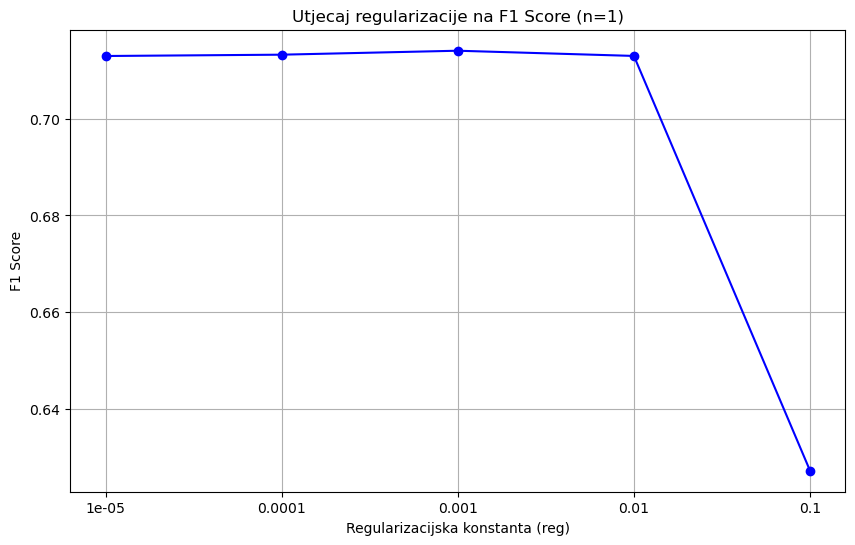

In [19]:
import matplotlib.pyplot as plt

reg_konstante = []
f1_rezultati = []
trenutni_reg = 1e-5

for i in range(5):
    print(f"Treniranje s reg = {trenutni_reg}...")
    
    model = PITF(n_U, n_I, n_T, 2)

    model.fit_bpr(train, steps=1000000, reg=trenutni_reg)
    
 
    metrike = metrike_at_n(model, test, 1)
    f1_score = metrike[2] 
    
    reg_konstante.append(str(trenutni_reg))
    f1_rezultati.append(f1_score)
    
    trenutni_reg *= 10

plt.figure(figsize=(10, 6))
plt.plot(reg_konstante, f1_rezultati, marker='o', linestyle='-', color='b')
plt.title('Utjecaj regularizacije na F1 Score (n=1)')
plt.xlabel('Regularizacijska konstanta (reg)')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()


In [22]:
model3= KanonskaDekompozicija(n_U,n_I,n_T,10)
model3.fit_bpr(train)
metrike_at_n(model3,test,1)

BPR-CD: 100%|██████████| 200000/200000 [00:17<00:00, 11648.37step/s]


(0.34660636159394587, 0.34660636159394587, 0.34660636159394587)

In [23]:
model4= KanonskaDekompozicija(n_U,n_I,n_T,1000)
model4.fit_bpr(train)
metrike_at_n(model4,test,1)

BPR-CD: 100%|██████████| 200000/200000 [01:00<00:00, 3298.68step/s]


(0.33197351306609907, 0.33197351306609907, 0.33197351306609907)

In [24]:
model5= KanonskaDekompozicija(n_U,n_I,n_T,10000)
model5.fit_bpr(train)
metrike_at_n(model5,test,1)

BPR-CD: 100%|██████████| 200000/200000 [11:05<00:00, 300.54step/s] 


(0.33499615702967955, 0.33499615702967955, 0.33499615702967955)

Treniranje s k = 10...


BPR-CD: 100%|██████████| 100000/100000 [00:08<00:00, 12291.56step/s]


Treniranje s k = 100...


BPR-CD: 100%|██████████| 100000/100000 [00:07<00:00, 12789.80step/s]


Treniranje s k = 500...


BPR-CD: 100%|██████████| 100000/100000 [00:22<00:00, 4497.68step/s]


Treniranje s k = 1000...


BPR-CD: 100%|██████████| 100000/100000 [00:40<00:00, 2444.91step/s]


Treniranje s k = 10000...


BPR-CD: 100%|██████████| 100000/100000 [04:58<00:00, 334.78step/s]


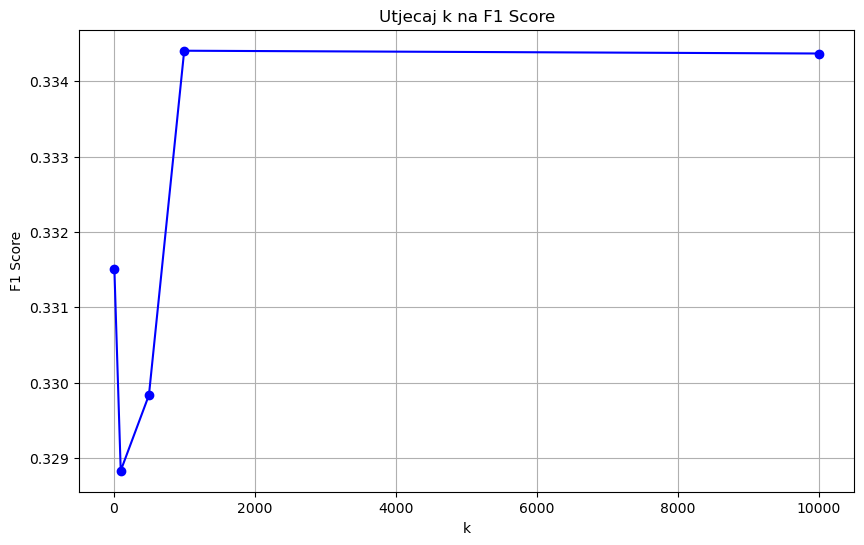

In [18]:
import matplotlib.pyplot as plt

rangovi = [10,100,500,1000,10000]
f1_rezultati = []
k = 10

for k in rangovi:
    print(f"Treniranje s k = {k}...")
    
    model=KanonskaDekompozicija(n_U,n_I,n_T,k)

    model.fit_bpr(train,steps=100000)
    
 
    metrike = metrike_at_n(model, test, 1)
    f1_score = metrike[2] 
    
    f1_rezultati.append(f1_score)

plt.figure(figsize=(10, 6))
plt.plot(rangovi, f1_rezultati, marker='o', linestyle='-', color='b')
plt.title('Utjecaj k na F1 Score')
plt.xlabel('k')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()

In [19]:
model6= KanonskaDekompozicija(n_U,n_I,n_T,100,30,2)
model6.fit_bpr(train,steps=10000)
metrike_at_n(model6,test,1)

BPR-CD: 100%|██████████| 10000/10000 [00:01<00:00, 7148.06step/s]


(0.3368966969318627, 0.3368966969318627, 0.3368966969318627)